# This is an example notebook to show how our code can be used for a densification-only scenario modelling

## Imports

We first import the required modules

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from SuSceMod.simulation import logger, data_utilities, input_handling, scenarios

## Setup of the simulation

Need to first add the paths to the input and output folders

In [2]:
input_folder = './input_rasters/'

output_folder = './output/densification_only/'
os.makedirs(output_folder, exist_ok=True)

suitability_maps_folder = './suitability_maps/'

In [3]:
initial_year = 2020
final_year = 2030

In [4]:
prob_years = [2010, 2020]
change_years = [2010, 2020]

In [5]:
initial_built_up_map = data_utilities.load_raster_data(
    input_folder + f'BU_{initial_year}.tif'
) 

Path to the suitability maps must be added, to guide the allocation. These can be outputs of ML models likes MultiNomial Logistic regression in our case 

In [6]:
suitability_maps_path = suitability_maps_folder + f"{str(prob_years[0])[-2:]}_{str(prob_years[1])[-2:]}/"
prob_maps_dict, prob_map_paths = input_handling.load_prob_maps(suitability_maps_path, prob_years)

Give the paths to the maps to calculate the change maps, and in turn, the demand

In [7]:
initial_demand_map = input_folder + f'BU_{change_years[0]}.tif'
final_demand_map   = input_folder + f'BU_{change_years[1]}.tif'

change_maps_dict, classes = input_handling.calculate_change_maps(
    initial_demand_map, final_demand_map
)

In [8]:
annual_rates, period_counts, crosstab_df = input_handling.calculate_change_rates(
    change_maps_dict, change_years
)


Crosstab (counts, incl. no-change on diagonal):
         0      1       2      3
0  1381843   4906    3538    744
1        0  72337    5613    202
2        0      0  159056   3665
3        0      0       0  58216

Annual change rates (cells/year):
    -> 0 → 1: 490.6
    -> 0 → 2: 353.8
    -> 0 → 3: 74.4
    -> 1 → 2: 561.3
    -> 1 → 3: 20.2
    -> 2 → 3: 366.5


## Running the simulation

In a densification-only scenario, the demand for expansion (class 0 to 1, 2 and 3) falls linearly to zero by `final_year`. The cells this frees up are added to the densification demand (1 to 2, 1 to 3 and 2 to 3, matched in that order), so total growth stays the same while it shifts from expansion to densification

In [9]:
simulated_maps, output_paths, class_counts_dict = scenarios.simulate_densification_only_scenario(
    initial_year,
    final_year,
    initial_built_up_map, 
    prob_maps_dict,
    annual_rates,
    output_folder,
    randomness='gumbel',
    seed=2118
)


Demands (cells/year):
    -> 0 → 1: 490.6
    -> 0 → 2: 353.8
    -> 0 → 3: 74.4
    -> 1 → 2: 561.3
    -> 1 → 3: 20.2
    -> 2 → 3: 366.5

Yearly decrease in expansion demand (cells/year):
    -> 0 → 1: 49.06
    -> 0 → 2: 35.38
    -> 0 → 3: 7.44

###################################################################

Current year: 2020
Simulating for year: 2021

Current demands (cells/year):
    -> 0 → 1: 441.54
    -> 0 → 2: 318.42
    -> 0 → 3: 66.96
    -> 1 → 2: 610.36
    -> 1 → 3: 55.58
    -> 2 → 3: 373.94



------------------------------------------------------

Year 2021: Updated built-up map summary (value: count):
{0.0: 1381016, 1.0: 77019, 2.0: 168761, 3.0: 63324, 'nan': 2004749}

###################################################################

Current year: 2021
Simulating for year: 2022

Current demands (cells/year):
    -> 0 → 1: 392.48
    -> 0 → 2: 283.04
    -> 0 → 3: 59.52
    -> 1 → 2: 610.36
    -> 1 → 3: 55.58
    -> 2 → 3: 373.94



------------------------------------------------------

Year 2022: Updated built-up map summary (value: count):
{0.0: 1380281, 1.0: 76745, 2.0: 169280, 3.0: 63814, 'nan': 2004749}

Changes from previous year summary (value: count):
{0: -735, 1: -274, 2: 519, 3: 490}

###################################################################

Current year: 2022
Simulating for year: 2023

Current demands (cells/year):
    -> 0 → 1: 343.42
    -> 0 → 2: 247.66
    -> 0 → 3: 52.08
    -> 1 → 2: 610.36
    -> 1 → 3: 55.58
    -> 2 → 3: 373.94



------------------------------------------------------

Year 2023: Updated built-up map summary (value: count):
{0.0: 1379638, 1.0: 76422, 2.0: 169764, 3.0: 64296, 'nan': 2004749}

Changes from previous year summary (value: count):
{0: -643, 1: -323, 2: 484, 3: 482}

###################################################################

Current year: 2023
Simulating for year: 2024

Current demands (cells/year):
    -> 0 → 1: 294.36
    -> 0 → 2: 212.28
    -> 0 → 3: 44.64
    -> 1 → 2: 610.36
    -> 1 → 3: 55.58
    -> 2 → 3: 373.94



------------------------------------------------------

Year 2024: Updated built-up map summary (value: count):
{0.0: 1379087, 1.0: 76050, 2.0: 170212, 3.0: 64771, 'nan': 2004749}

Changes from previous year summary (value: count):
{0: -551, 1: -372, 2: 448, 3: 475}

###################################################################

Current year: 2024
Simulating for year: 2025

Current demands (cells/year):
    -> 0 → 1: 245.3
    -> 0 → 2: 176.9
    -> 0 → 3: 37.2
    -> 1 → 2: 610.36
    -> 1 → 3: 55.58
    -> 2 → 3: 373.94


...


------------------------------------------------------

Year 2026: Updated built-up map summary (value: count):
{0.0: 1378260, 1.0: 75159, 2.0: 171003, 3.0: 65698, 'nan': 2004749}

Changes from previous year summary (value: count):
{0: -368, 1: -470, 2: 378, 3: 460}

###################################################################

Current year: 2026
Simulating for year: 2027

Current demands (cells/year):
    -> 0 → 1: 147.18
    -> 0 → 2: 106.14
    -> 0 → 3: 22.32
    -> 1 → 2: 610.36
    -> 1 → 3: 55.58
    -> 2 → 3: 373.94



------------------------------------------------------

Year 2027: Updated built-up map summary (value: count):
{0.0: 1377985, 1.0: 74640, 2.0: 171345, 3.0: 66150, 'nan': 2004749}

Changes from previous year summary (value: count):
{0: -275, 1: -519, 2: 342, 3: 452}

###################################################################

Current year: 2027
Simulating for year: 2028

Current demands (cells/year):
    -> 0 → 1: 98.12
    -> 0 → 2: 70.76
    -> 0 → 3: 14.88
    -> 1 → 2: 610.36
    -> 1 → 3: 55.58
    -> 2 → 3: 373.94



------------------------------------------------------

Year 2028: Updated built-up map summary (value: count):
{0.0: 1377801, 1.0: 74072, 2.0: 171652, 3.0: 66595, 'nan': 2004749}

Changes from previous year summary (value: count):
{0: -184, 1: -568, 2: 307, 3: 445}

###################################################################

Current year: 2028
Simulating for year: 2029

Current demands (cells/year):
    -> 0 → 1: 49.06
    -> 0 → 2: 35.38
    -> 0 → 3: 7.44
    -> 1 → 2: 610.36
    -> 1 → 3: 55.58
    -> 2 → 3: 373.94



------------------------------------------------------

Year 2029: Updated built-up map summary (value: count):
{0.0: 1377710, 1.0: 73455, 2.0: 171923, 3.0: 67032, 'nan': 2004749}

Changes from previous year summary (value: count):
{0: -91, 1: -617, 2: 271, 3: 437}

###################################################################

Current year: 2029
Simulating for year: 2030

Current demands (cells/year):
    -> 0 → 1: 0.0
    -> 0 → 2: 0.0
    -> 0 → 3: 0.0
    -> 1 → 2: 610.36
    -> 1 → 3: 55.58
    -> 2 → 3: 373.94



------------------------------------------------------

Year 2030: Updated built-up map summary (value: count):
{0.0: 1377710, 1.0: 72789, 2.0: 172159, 3.0: 67462, 'nan': 2004749}

Changes from previous year summary (value: count):
{0: 0, 1: -666, 2: 236, 3: 430}


In [10]:
counts_csv_file = os.path.join(output_folder, f"class_counts_{initial_year}_{final_year}.csv")
data_utilities.save_counts_to_csv(class_counts_dict, counts_csv_file)

A template raster is required to save the simulated rasters with proper extent and boundaries. We can simply use the `initial_built_up_map` for this purpose

In [11]:
template_raster_path = input_folder + f'BU_{change_years[0]}.tif'

In [12]:
for year in simulated_maps.keys():
    data_utilities.writeraster(template_raster_path, output_paths[year], simulated_maps[year])

## View results of the simulation

### Understanding the trend of each density class over time

Convert the class counts dictionary `class_counts_dict` to a dataframe for easier processing

In [13]:
class_counts_df = data_utilities.counts_to_df(class_counts_dict, exclude_nan=True)

We can now filter to get the required values. Here, for example, we look at the year 2025

In [14]:
class_counts_df[class_counts_df['year']==2025]

,year,category,count
16,2025,0.0,1378628
17,2025,1.0,75629
18,2025,2.0,170625
19,2025,3.0,65238


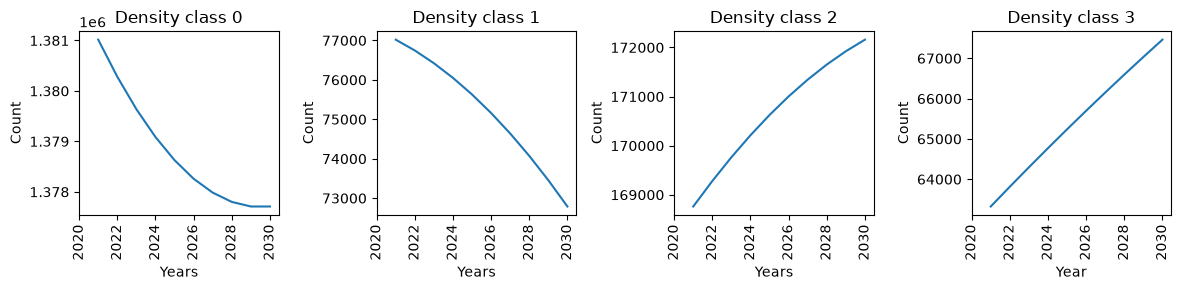

In [15]:
categories = class_counts_df["category"].unique()
n = len(categories)

fig, axes = plt.subplots(1, n, figsize=(12, 3), sharex=True)

for ax, cat in zip(axes, categories):
    sub = class_counts_df[class_counts_df["category"] == cat]
    ax.plot(sub["year"], sub["count"])
    ax.set_title(f"Density class {int(cat)}")
    ax.set_ylabel("Count")
    ax.set_xlabel("Years")
    ax.tick_params(axis="x", labelrotation=90)
    years = range(initial_year, final_year+1, 2)
    ax.set_xticks(years)

axes[-1].set_xlabel("Year")
plt.tight_layout()
plt.show()


### Quick visualization of the simulated rasters

For example, we look at the density classes for the raster of year 2025

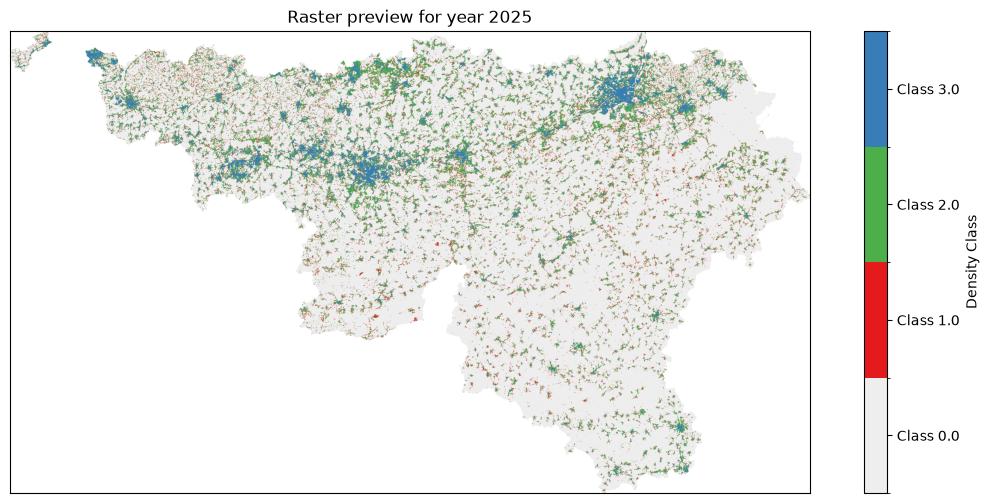

In [16]:
example_year = 2025

example_raster = data_utilities.load_raster_data(output_folder + f"sim_{example_year}.tif")
data_utilities.plot_raster_classes(
    example_raster, 
    colors=["#eeeeee", "#e41a1c", "#4daf4a", "#377eb8"], 
    title=f'Raster preview for year {example_year}'
)